In [ ]:
### Knowledge involved
### 1) perform logistic regression using 'sklearn'
### 2) Basic array construction with numpy
### 3) Basic visualization with matplotlib.pyplot
### Important note: Learn to check documentation of the package by yourself to learn new functions!
### e.g. for numpy: https://numpy.org/doc/stable/
###      for matplotlib: https://matplotlib.org/stable/api/index
###      for sklearn: https://scikit-learn.org/stable/api/index.html

In [ ]:
### We aim to perform a 2D classification task with logistic regression.
###       Feature 1: Mean radius (normalized)
###       Feature 2: Mean texture (normalized)
###       Classes: Malignant (1), Benign (0)
### The input data are arranged as [x1, x2] for each patient.
### The output data are binary labels, where 1 means malignant and 0 means benign.
### This time, we will directly use sklearn.linear_model.LogisticRegression
### and let sklearn handle the optimization for us.

In [2]:
### Let's first construct the input matrix and output vector
import numpy as np

### Each row in X is one data point
### The first column is feature 1
### The second column is feature 2
X = np.array([[1.0, 0.5],
              [0.8, 0.7],
              [0.3, 0.2],
              [0.1, 0.1],
              [0.5, 0.3]])

### y is the label vector
### 1 means malignant
### 0 means benign
y = np.array([1, 1, 0, 0, 0])

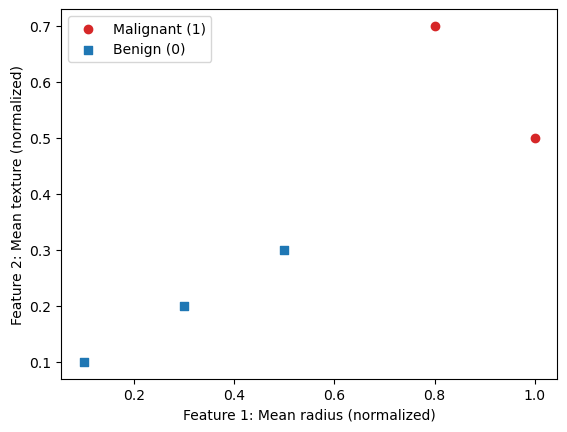

In [3]:
### Now lets visualize the data and see what it looks like
import matplotlib.pyplot as plt

### Select the points with label 1
### y==1 gives a boolean vector, and X[y==1] picks those rows in X
X_pos = X[y==1]

### Select the points with label 0
X_neg = X[y==0]

### Plot the positive class
plt.scatter(X_pos[:,0], X_pos[:,1], marker='o', color='tab:red', label='Malignant (1)')

### Plot the negative class
plt.scatter(X_neg[:,0], X_neg[:,1], marker='s', color='tab:blue', label='Benign (0)')

### Label the x-axis and y-axis
plt.xlabel('Feature 1: Mean radius (normalized)')
plt.ylabel('Feature 2: Mean texture (normalized)')

### Show the legend
plt.legend()

### From the figure, it seems that the two classes can be separated reasonably well
### so logistic regression should work nicely on this small example

In [5]:
### Now lets define the logistic regression model
from sklearn.linear_model import LogisticRegression

### LogisticRegression() creates a logistic regression classifier
### In C =1e6, C denotes inverse of regularization strength
### Here we set a very large C value so that the regularization effect is very weak
### This makes the example closer to the logistic regression presented in the class
### solver='lbfgs' is a standard optimization algorithm used by sklearn
### There are other solvers available for optimization
### Check https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
model = LogisticRegression(C=1e6, solver='lbfgs')

In [6]:
### Next, lets fit the model to the training data
### Similar to linear regression, .fit(X,y) means:
###     X = input matrix
###     y = target labels
### The model will automatically learn the intercept and coefficients from data
model.fit(X, y)

### Similar to linear regression
### after fitting, sklearn stores the learned parameters inside the model
### model.intercept_ is the bias term
### model.coef_ contains the coefficients for each feature
print('Intercept:')
print(model.intercept_)
print('Coefficients:')
print(model.coef_)

Intercept:
[-29.08758861]
Coefficients:
[[25.63249201 23.95084946]]


In [7]:
### Now lets use the fitted model to make predictions
### predict_proba(X) returns the class probabilities for each row in X
### The first column is P(class 0)
### The second column is P(class 1)
prob = model.predict_proba(X)

### predict(X) returns the final predicted class labels
pred = model.predict(X)

print('Predicted probabilities [P(class 0), P(class 1)]:')
print(prob)
print('Predicted labels:')
print(pred)
print('Actual labels:')
print(y)

Predicted probabilities [P(class 0), P(class 1)]:
[[1.99334250e-04 9.99800666e-01]
 [2.79005608e-04 9.99720994e-01]
 [9.99999939e-01 6.12886497e-08]
 [1.00000000e+00 3.31740073e-11]
 [9.99886783e-01 1.13217367e-04]]
Predicted labels:
[1 1 0 0 0]
Actual labels:
[1 1 0 0 0]


In [8]:
### We can also evaluate how well the model performs on the training data
### score(X,y) returns the classification accuracy
acc = model.score(X, y)

### For binary classification, model.coef_[0,0] is the coefficient of feature 1
### and model.coef_[0,1] is the coefficient of feature 2
w0 = model.intercept_[0]
w1 = model.coef_[0,0]
w2 = model.coef_[0,1]

print('Learned logistic regression model:')
print('Training accuracy:', acc)

### The decision boundary is where the logit equals zero
### That is:
###     w0 + w1*x1 + w2*x2 = 0
print()
print('Decision boundary:')
print(str(w0) + ' + ' + str(w1) + '*x1 + ' + str(w2) + '*x2 = 0')

Learned logistic regression model:
Training accuracy: 1.0

Decision boundary:
-29.087588607064177 + 25.63249201409121*x1 + 23.950849464952732*x2 = 0
